In [63]:
import pandas as pd
from tqdm.auto import tqdm

tqdm.pandas()

from dti.data import load_chembl_endpoints
from dti.constants import ASSAY, ACT, SMILES

In [64]:
df = load_chembl_endpoints('../data/raw/chembl_endpoints.csv')

In [65]:
assay_sizes = df.groupby(ASSAY).nunique()[[SMILES]].rename(columns={SMILES: 'assay_size'})

In [66]:
df = df.join(assay_sizes, on='assay_id')

In [67]:
df = df[df['assay_size'] >= 20]

<Axes: >

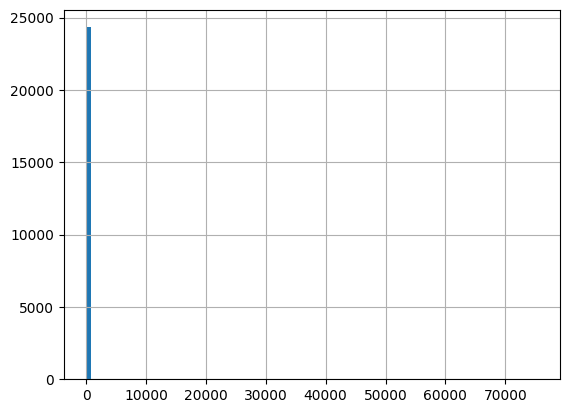

In [68]:
df.groupby(ASSAY).nunique()[SMILES].hist(bins=100)

In [69]:
def mark_test_samples(group, frac=0.2, seed=42):
    n = max(1, int(len(group) * frac))
    test_idx = group.sample(n=n, random_state=seed).index
    group["test"] = False
    group.loc[test_idx, "test"] = True
    return group

df = df.groupby("assay_id", group_keys=False).progress_apply(mark_test_samples)

  0%|          | 0/24434 [00:00<?, ?it/s]

In [70]:
df.to_csv('../data/raw/chembl_endpoints_split.csv', index=False)